# Retrieval-Augmented Classification — Stratified Analysis
## 9-Partition Label | FST-Resampled Subset

**Pipeline:**
1. Standard kNN — similarity-weighted voting over OpenCLIP embeddings
2. Tone-aware kNN — same-tone neighbor boosting for Dark (IV-VI) queries
3. FST-resampled evaluation (matching full Fitzpatrick17k distribution)
4. Per-FST type and per-tone-group stratified accuracy
5. 9-partition disease category × Fitzpatrick heatmaps
6. Equity analysis — Dark vs Light gap per disease category
7. k sweep and boost sweep

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [4]:
# ── CONFIG — edit paths as needed ─────────────────────────────────────────────
EMBEDDINGS_PATH = '/content/drive/MyDrive/277Project/df_dermaamin_with_embeddings.npy'
METADATA_PATH   = '/content/drive/MyDrive/277Project/df_dermaamin_with_embeddings.csv'

K            = 10     # optimal from sweep
N_SPLITS     = 5
# NOTE: boost sweep showed any value > 1.0 hurts dark accuracy at 9-partition level.
# TONE_BOOST = 1.0 means tone-aware == standard. Keep here for documentation;
# set > 1.0 only if testing alternative retrieval strategies.
TONE_BOOST   = 1.0
RANDOM_STATE = 42

TONE_COL    = 'tone_group'
DARK_GROUP  = 'Dark (IV-VI)'
LIGHT_GROUP = 'Light (I-III)'
FITZ_COL    = 'fitzpatrick_scale'


## 1. Load Data

In [5]:
def load_data(emb_path, meta_path):
    embeddings = np.load(emb_path)
    df = pd.read_csv(meta_path)
    df = df[df[TONE_COL].isin([LIGHT_GROUP, DARK_GROUP])].reset_index(drop=True)
    embeddings = normalize(embeddings[df['embedding_idx'].values], norm='l2')
    return embeddings, df.reset_index(drop=True)

embeddings, df = load_data(EMBEDDINGS_PATH, METADATA_PATH)
print(f'Embeddings : {embeddings.shape}')
print(f'Samples    : {len(df)}')
print(df[FITZ_COL].value_counts().sort_index().rename('count').to_frame())


Embeddings : (12631, 512)
Samples    : 12631
                   count
fitzpatrick_scale       
-1                   409
 1                  2780
 2                  4137
 3                  2298
 4                  1689
 5                   891
 6                   427


In [6]:
# ── Resample to match full Fitzpatrick17k FST distribution ────────────────────
# Approximate counts from full 16,577-image dataset (excl. unknown)
FULL_DIST  = {1: 3200, 2: 5200, 3: 2600, 4: 1800, 5: 1500, 6: 1100}
FULL_TOTAL = sum(FULL_DIST.values())
FULL_PROPS = {k: v / FULL_TOTAL for k, v in FULL_DIST.items()}

subset_counts = df[df[FITZ_COL] > 0][FITZ_COL].value_counts().to_dict()
max_total     = int(min(subset_counts[t] / FULL_PROPS[t]
                        for t in FULL_PROPS if t in subset_counts))
target_counts = {t: int(FULL_PROPS[t] * max_total) for t in FULL_PROPS}

print(f"{'Type':<8} {'Available':>10} {'Target':>8} {'Full %':>8} {'New %':>8}")
total_target = sum(target_counts.values())
for t in sorted(target_counts):
    avail = subset_counts.get(t, 0)
    tgt   = target_counts[t]
    print(f"  FST {t}   {avail:>10}   {tgt:>7}   {FULL_PROPS[t]*100:>6.1f}%   {tgt/total_target*100:>6.1f}%")
print(f"\nTotal resampled: {total_target}  (from original {len(df[df[FITZ_COL]>0])})")


Type      Available   Target   Full %    New %
  FST 1         2780      1242     20.8%     20.8%
  FST 2         4137      2018     33.8%     33.8%
  FST 3         2298      1009     16.9%     16.9%
  FST 4         1689       698     11.7%     11.7%
  FST 5          891       582      9.7%      9.7%
  FST 6          427       427      7.1%      7.1%

Total resampled: 5976  (from original 12222)


In [7]:
import random
random.seed(RANDOM_STATE)

resampled_idx = []
for t, n in target_counts.items():
    pool    = df[df[FITZ_COL] == t].index.tolist()
    sampled = random.sample(pool, n)
    resampled_idx.extend(sampled)

resampled_idx = sorted(resampled_idx)
df_resampled  = df.loc[resampled_idx].reset_index(drop=True)
emb_resampled = embeddings[resampled_idx]

print('Resampled FST distribution:')
rc = df_resampled[FITZ_COL].value_counts().sort_index()
for t, n in rc.items():
    print(f'  FST {t}: n={n:4d}  ({n/len(df_resampled)*100:.1f}%)')
light = df_resampled[df_resampled[TONE_COL] == LIGHT_GROUP].shape[0]
dark  = df_resampled[df_resampled[TONE_COL] == DARK_GROUP].shape[0]
print(f'\nLight (I-III): {light} ({light/len(df_resampled)*100:.1f}%)')
print(f'Dark  (IV-VI): {dark}  ({dark/len(df_resampled)*100:.1f}%)')


Resampled FST distribution:
  FST 1: n=1242  (20.8%)
  FST 2: n=2018  (33.8%)
  FST 3: n=1009  (16.9%)
  FST 4: n= 698  (11.7%)
  FST 5: n= 582  (9.7%)
  FST 6: n= 427  (7.1%)

Light (I-III): 4269 (71.4%)
Dark  (IV-VI): 1707  (28.6%)


## 2. kNN Core Functions

In [8]:
def weighted_vote(neighbor_labels, neighbor_sims):
    scores = defaultdict(float)
    for lbl, sim in zip(neighbor_labels, neighbor_sims):
        scores[lbl] += float(sim)
    return max(scores, key=scores.get)


def knn_predict(query_embs, train_embs, train_labels, k=K):
    """Standard kNN with similarity-weighted voting."""
    sim   = query_embs @ train_embs.T
    preds = []
    for i in range(len(query_embs)):
        top_k = np.argsort(sim[i])[::-1][:k]
        preds.append(weighted_vote(train_labels[top_k], sim[i][top_k]))
    return np.array(preds)


def tone_aware_knn_predict(query_embs, query_tones,
                           train_embs, train_labels, train_tones,
                           k=K, boost=TONE_BOOST):
    """
    Tone-aware kNN:
    - Dark (IV-VI) queries: boost same-tone neighbor similarities before
      selecting top-k, vote with original (unboosted) similarities.
    - Light (I-III) queries: standard retrieval.
    Note: boost sweep showed boost > 1.0 hurts dark accuracy at 9-partition level.
    """
    sim   = query_embs @ train_embs.T
    preds = []
    for i in range(len(query_embs)):
        raw = sim[i].copy()
        if query_tones[i] == DARK_GROUP:
            boosted = raw.copy()
            boosted[train_tones == DARK_GROUP] *= boost
            top_k = np.argsort(boosted)[::-1][:k]
            preds.append(weighted_vote(train_labels[top_k], raw[top_k]))
        else:
            top_k = np.argsort(raw)[::-1][:k]
            preds.append(weighted_vote(train_labels[top_k], raw[top_k]))
    return np.array(preds)

print('Core functions defined.')


Core functions defined.


## 3. Cross-Validation — Collect All Predictions

In [9]:
def run_cv_collect(embeddings, df, label_col='nine_partition_label', k=K):
    """Run stratified k-fold CV and return per-sample predictions."""
    labels = df[label_col].values
    tones  = df[TONE_COL].values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    out_idx, std_preds_all, tone_preds_all = [], [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(embeddings, labels)):
        tr_embs, tr_labels, tr_tones = embeddings[tr_idx], labels[tr_idx], tones[tr_idx]
        te_embs, te_labels, te_tones = embeddings[te_idx], labels[te_idx], tones[te_idx]

        std_preds  = knn_predict(te_embs, tr_embs, tr_labels, k=k)
        tone_preds = tone_aware_knn_predict(
            te_embs, te_tones, tr_embs, tr_labels, tr_tones, k=k)

        out_idx.extend(te_idx)
        std_preds_all.extend(std_preds)
        tone_preds_all.extend(tone_preds)

        acc_s = accuracy_score(te_labels, std_preds)
        acc_t = accuracy_score(te_labels, tone_preds)
        print(f'  Fold {fold+1}/{N_SPLITS}  std={acc_s:.3f}  tone-aware={acc_t:.3f}')

    order = np.argsort(out_idx)
    out_df = df.copy()
    out_df['true_label']         = labels
    out_df['pred_standard']      = np.array(std_preds_all)[order]
    out_df['pred_tone_aware']    = np.array(tone_preds_all)[order]
    out_df['correct_standard']   = (out_df['true_label'] == out_df['pred_standard']).astype(int)
    out_df['correct_tone_aware'] = (out_df['true_label'] == out_df['pred_tone_aware']).astype(int)
    return out_df


print(f'Running CV — 9-partition, FST-resampled, k={K}, boost={TONE_BOOST}...')
pred_df = run_cv_collect(emb_resampled, df_resampled, label_col='nine_partition_label', k=K)


Running CV — 9-partition, FST-resampled, k=10, boost=1.0...
  Fold 1/5  std=0.695  tone-aware=0.695
  Fold 2/5  std=0.711  tone-aware=0.711
  Fold 3/5  std=0.717  tone-aware=0.717
  Fold 4/5  std=0.710  tone-aware=0.710
  Fold 5/5  std=0.707  tone-aware=0.707


## 4. Per-Fitzpatrick Scale Accuracy

In [10]:
# Per Fitzpatrick TYPE (I-VI) accuracy table
fitz_df = pred_df[pred_df[FITZ_COL] > 0]

fitz_table = (
    fitz_df.groupby(FITZ_COL)
    .agg(
        n          = (FITZ_COL,             'count'),
        standard   = ('correct_standard',   'mean'),
        tone_aware = ('correct_tone_aware', 'mean'),
    )
    .round(3)
)
fitz_table['delta'] = (fitz_table['tone_aware'] - fitz_table['standard']).round(3)
fitz_table.index    = [f'Type {i}' for i in fitz_table.index]

# Grouped (I-III vs IV-VI) accuracy table
group_table = (
    fitz_df.groupby(TONE_COL)
    .agg(
        n          = (TONE_COL,             'count'),
        standard   = ('correct_standard',   'mean'),
        tone_aware = ('correct_tone_aware', 'mean'),
    )
    .round(3)
)
group_table['delta'] = (group_table['tone_aware'] - group_table['standard']).round(3)

print('=== Per Fitzpatrick Type ===')
display(fitz_table)
print('\n=== Grouped (I-III vs IV-VI) ===')
display(group_table)


=== Per Fitzpatrick Type ===


,n,standard,tone_aware,delta
Type 1,1242,0.707,0.707,0.0
Type 2,2018,0.701,0.701,0.0
Type 3,1009,0.713,0.713,0.0
Type 4,698,0.706,0.706,0.0
Type 5,582,0.710,0.710,0.0
Type 6,427,0.738,0.738,0.0



=== Grouped (I-III vs IV-VI) ===


,n,standard,tone_aware,delta
tone_group,,,,
Dark (IV-VI),1707,0.715,0.715,0.0
Light (I-III),4269,0.705,0.705,0.0


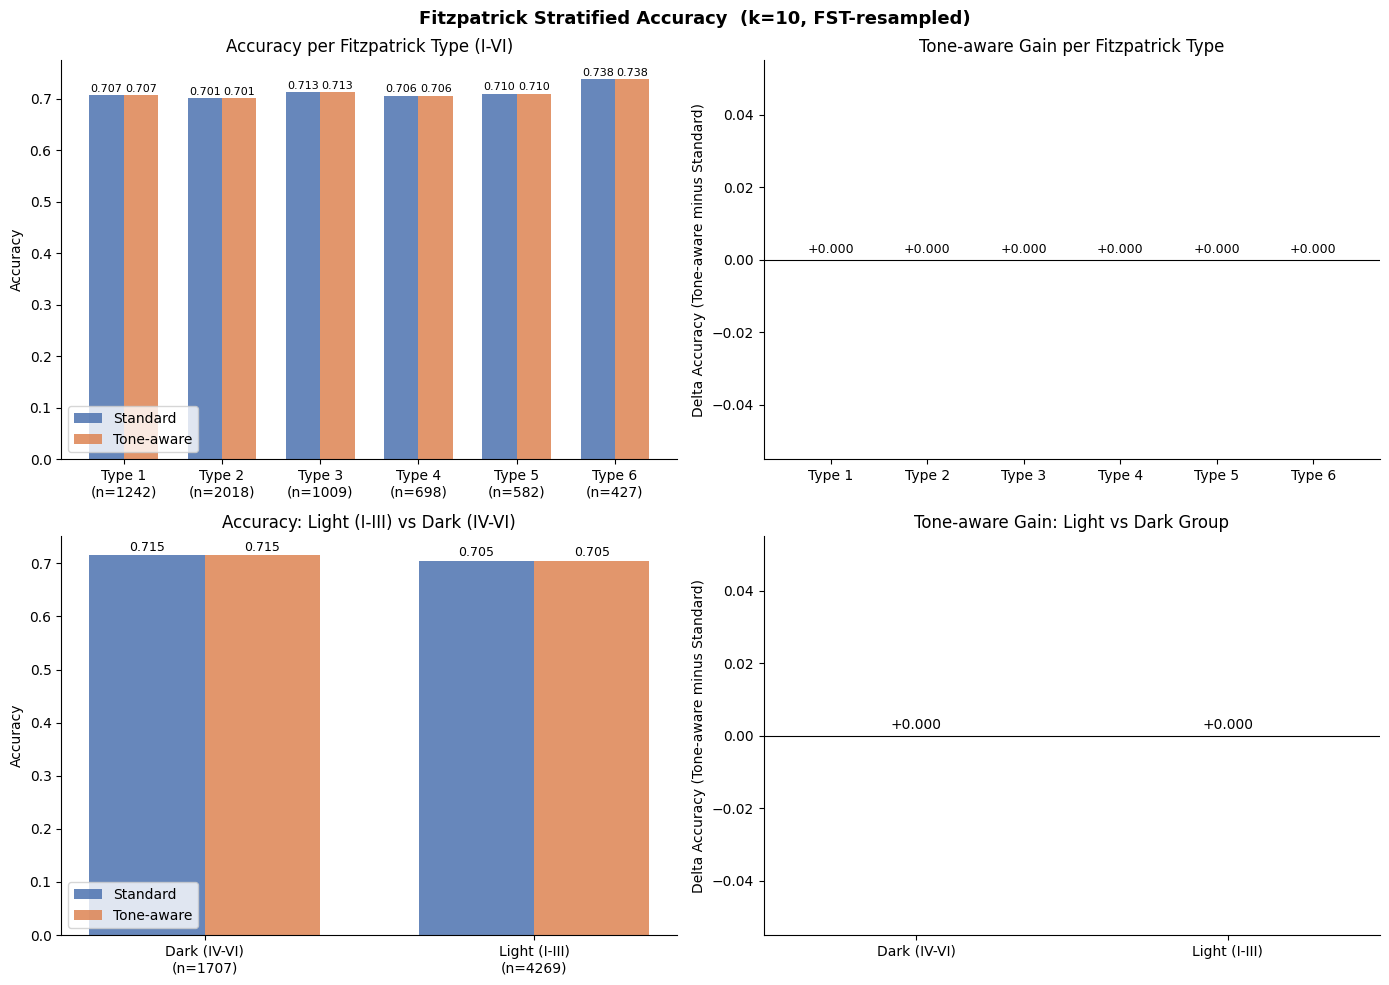

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: accuracy per FST type
ax = axes[0, 0]
x, w = np.arange(len(fitz_table)), 0.35
b1 = ax.bar(x - w/2, fitz_table['standard'],  w, label='Standard',   color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, fitz_table['tone_aware'], w, label='Tone-aware', color='#DD8452', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={fitz_table["n"].iloc[j]})'
                    for j, t in enumerate(fitz_table.index)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy per Fitzpatrick Type (I-VI)')
ax.legend(); sns.despine(ax=ax)

# Top right: delta per FST type
ax = axes[0, 1]
bar_colors = ['#C44E52' if d < 0 else '#55A868' for d in fitz_table['delta']]
bars = ax.bar(x, fitz_table['delta'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, fitz_table['delta']):
    ax.text(bar.get_x() + bar.get_width()/2,
            d + (0.001 if d >= 0 else -0.003), f'{d:+.3f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(fitz_table.index)
ax.set_ylabel('Delta Accuracy (Tone-aware minus Standard)')
ax.set_title('Tone-aware Gain per Fitzpatrick Type')
sns.despine(ax=ax)

# Bottom left: accuracy by tone group
ax = axes[1, 0]
xg, wg = np.arange(len(group_table)), 0.35
b1 = ax.bar(xg - wg/2, group_table['standard'],  wg, label='Standard',   color='#4C72B0', alpha=0.85)
b2 = ax.bar(xg + wg/2, group_table['tone_aware'], wg, label='Tone-aware', color='#DD8452', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_xticks(xg)
ax.set_xticklabels([f'{g}\n(n={group_table["n"].iloc[j]})'
                    for j, g in enumerate(group_table.index)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Light (I-III) vs Dark (IV-VI)')
ax.legend(); sns.despine(ax=ax)

# Bottom right: delta by tone group
ax = axes[1, 1]
bar_colors = ['#C44E52' if d < 0 else '#55A868' for d in group_table['delta']]
bars = ax.bar(xg, group_table['delta'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, group_table['delta']):
    ax.text(bar.get_x() + bar.get_width()/2,
            d + (0.001 if d >= 0 else -0.003), f'{d:+.3f}',
            ha='center', va='bottom' if d >= 0 else 'top', fontsize=10)
ax.set_xticks(xg)
ax.set_xticklabels(group_table.index)
ax.set_ylabel('Delta Accuracy (Tone-aware minus Standard)')
ax.set_title('Tone-aware Gain: Light vs Dark Group')
sns.despine(ax=ax)

plt.suptitle(f'Fitzpatrick Stratified Accuracy  (k={K}, FST-resampled)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fitz_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


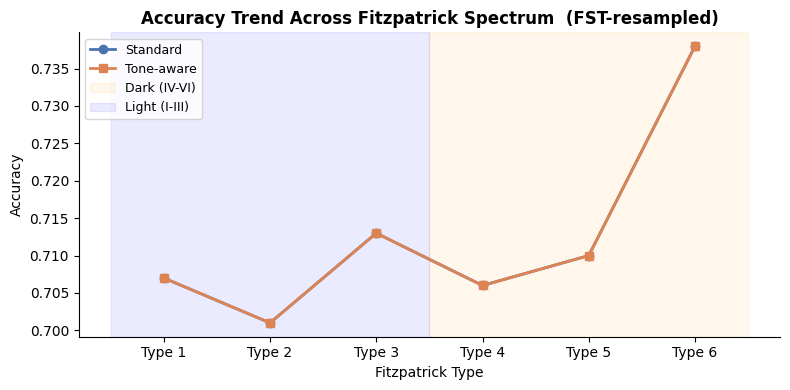

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
types = fitz_table.index.tolist()
ax.plot(types, fitz_table['standard'],  marker='o', label='Standard',   color='#4C72B0', linewidth=2)
ax.plot(types, fitz_table['tone_aware'], marker='s', label='Tone-aware', color='#DD8452', linewidth=2)
ax.axvspan(2.5, 5.5, alpha=0.08, color='orange', label='Dark (IV-VI)')
ax.axvspan(-0.5, 2.5, alpha=0.08, color='blue',   label='Light (I-III)')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Fitzpatrick Type')
ax.set_title('Accuracy Trend Across Fitzpatrick Spectrum  (FST-resampled)', fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/content/fitz_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Per-9-Partition Class Accuracy

In [13]:
label_col  = 'nine_partition_label'

part_table = (
    pred_df.groupby(label_col)
    .agg(
        n          = (label_col,            'count'),
        standard   = ('correct_standard',   'mean'),
        tone_aware = ('correct_tone_aware', 'mean'),
        pct_dark   = (TONE_COL, lambda x: (x == DARK_GROUP).mean()),
    )
    .round(3)
    .sort_values('standard', ascending=False)
)
part_table['delta'] = (part_table['tone_aware'] - part_table['standard']).round(3)
print('=== 9-Partition Accuracy ===')
display(part_table)


=== 9-Partition Accuracy ===


,n,standard,tone_aware,pct_dark,delta
nine_partition_label,,,,,
inflammatory,4011,0.960,0.960,0.293,0.0
malignant melanoma,229,0.424,0.424,0.170,0.0
malignant epidermal,386,0.394,0.394,0.166,0.0
genodermatoses,385,0.135,0.135,0.426,0.0
benign dermal,419,0.095,0.095,0.229,0.0
benign epidermal,359,0.089,0.089,0.295,0.0
benign melanocyte,88,0.057,0.057,0.261,0.0
malignant dermal,55,0.055,0.055,0.527,0.0
malignant cutaneous lymphoma,44,0.000,0.000,0.250,0.0


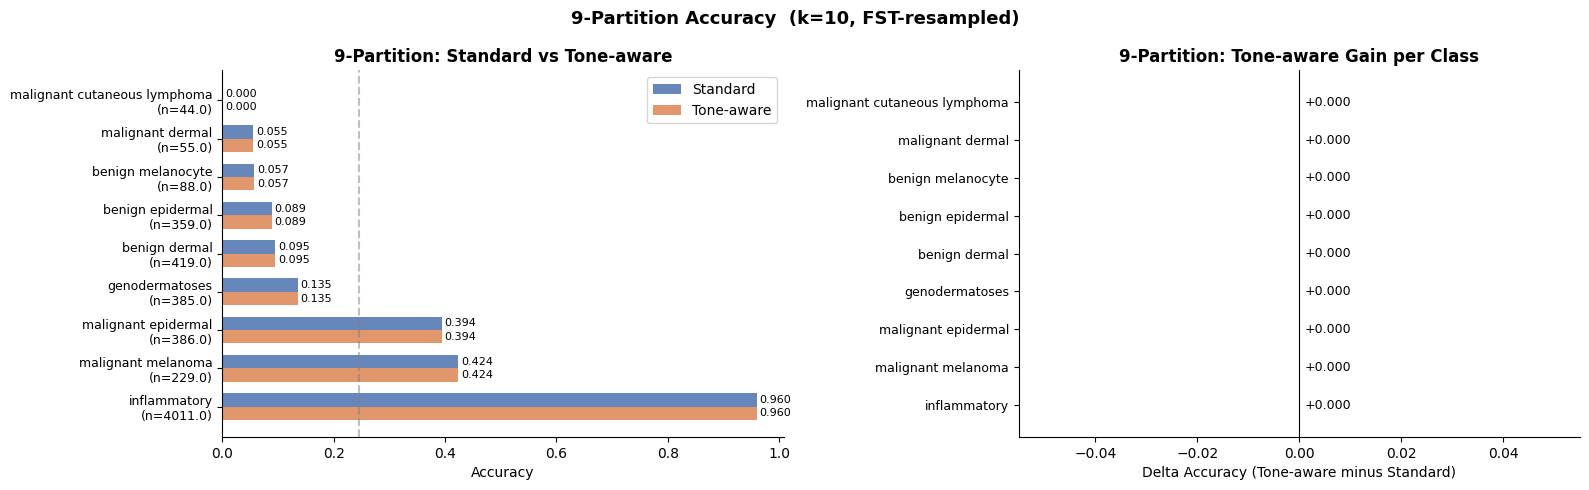

In [14]:
label_col = 'nine_partition_label'

part_table = (
    pred_df.groupby(label_col)
    .agg(
        n          = (label_col,            'count'),
        standard   = ('correct_standard',   'mean'),
        tone_aware = ('correct_tone_aware', 'mean'),
    )
    .sort_values('standard', ascending=False)
    .round(3)
)
part_table['delta'] = (part_table['tone_aware'] - part_table['standard']).round(3)

fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(part_table) * 0.55)))

ax = axes[0]
y, h = np.arange(len(part_table)), 0.35
ax.barh(y + h/2, part_table['standard'],  h, label='Standard',   color='#4C72B0', alpha=0.85)
ax.barh(y - h/2, part_table['tone_aware'], h, label='Tone-aware', color='#DD8452', alpha=0.85)
for vals, offset in [(part_table['standard'], h/2), (part_table['tone_aware'], -h/2)]:
    for j, v in enumerate(vals):
        ax.text(v + 0.005, j + offset, f'{v:.3f}', va='center', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([f'{lbl}\n(n={row.n})' for lbl, row in part_table.iterrows()], fontsize=9)
ax.set_xlabel('Accuracy')
ax.set_title('9-Partition: Standard vs Tone-aware', fontweight='bold')
ax.legend()
ax.axvline(part_table['standard'].mean(), color='gray', linestyle='--', alpha=0.5)
sns.despine(ax=ax)

ax = axes[1]
bar_colors = ['#C44E52' if d < 0 else '#55A868' for d in part_table['delta']]
bars = ax.barh(y, part_table['delta'], color=bar_colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, part_table['delta']):
    ax.text(d + (0.001 if d >= 0 else -0.001), bar.get_y() + bar.get_height()/2,
            f'{d:+.3f}', va='center', ha='left' if d >= 0 else 'right', fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(part_table.index, fontsize=9)
ax.set_xlabel('Delta Accuracy (Tone-aware minus Standard)')
ax.set_title('9-Partition: Tone-aware Gain per Class', fontweight='bold')
sns.despine(ax=ax)

plt.suptitle(f'9-Partition Accuracy  (k={K}, FST-resampled)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/barplot_nine_partition.png', dpi=150, bbox_inches='tight')
plt.show()


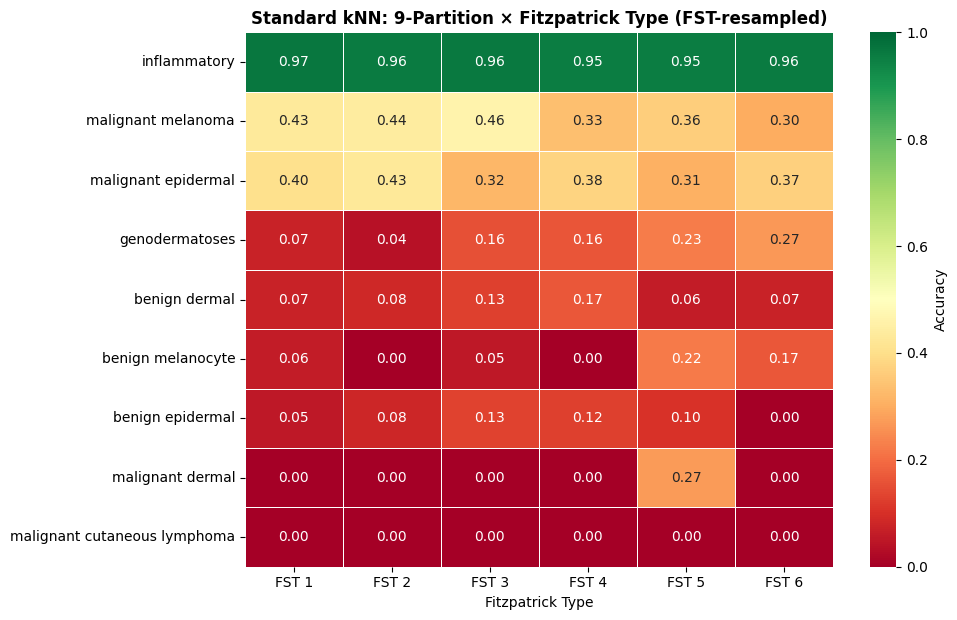

In [15]:
label_col = 'nine_partition_label'

pivot = (
    pred_df[pred_df[FITZ_COL] > 0]
    .groupby([label_col, FITZ_COL])['correct_standard']
    .mean()
    .unstack(FITZ_COL)
)
pivot.columns = [f'FST {c}' for c in pivot.columns]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.7)))
sns.heatmap(
    pivot, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Accuracy'}
)
ax.set_xlabel('Fitzpatrick Type')
ax.set_ylabel('')
ax.set_title('Standard kNN: 9-Partition × Fitzpatrick Type (FST-resampled)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/heatmap_nine_partition_fitz_standard.png', dpi=150, bbox_inches='tight')
plt.show()


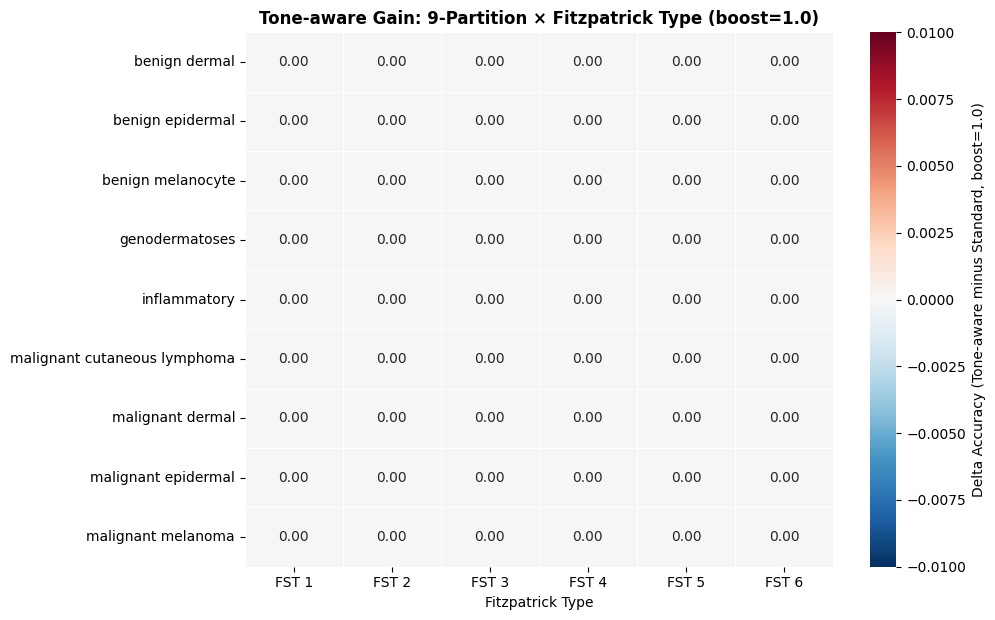

In [16]:
label_col = 'nine_partition_label'

delta_pivot = (
    pred_df[pred_df[FITZ_COL] > 0]
    .assign(delta=lambda x: x['correct_tone_aware'] - x['correct_standard'])
    .groupby([label_col, FITZ_COL])['delta']
    .mean()
    .unstack(FITZ_COL)
)
delta_pivot.columns = [f'FST {c}' for c in delta_pivot.columns]
delta_pivot = delta_pivot.loc[delta_pivot.mean(axis=1).sort_values(ascending=False).index]

vals = delta_pivot.values[~np.isnan(delta_pivot.values)]
lim  = max(abs(vals).max(), 0.01) if len(vals) else 0.1

fig, ax = plt.subplots(figsize=(10, max(4, len(delta_pivot) * 0.7)))
sns.heatmap(
    delta_pivot, ax=ax,
    cmap='RdBu_r', center=0, vmin=-lim, vmax=lim,
    annot=True, fmt='.2f', annot_kws={'size': 10},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': f'Delta Accuracy (Tone-aware minus Standard, boost={TONE_BOOST})'}
)
ax.set_xlabel('Fitzpatrick Type')
ax.set_ylabel('')
ax.set_title(f'Tone-aware Gain: 9-Partition × Fitzpatrick Type (boost={TONE_BOOST})', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/heatmap_nine_partition_fitz_delta.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Accuracy by Tone Group and FST Type

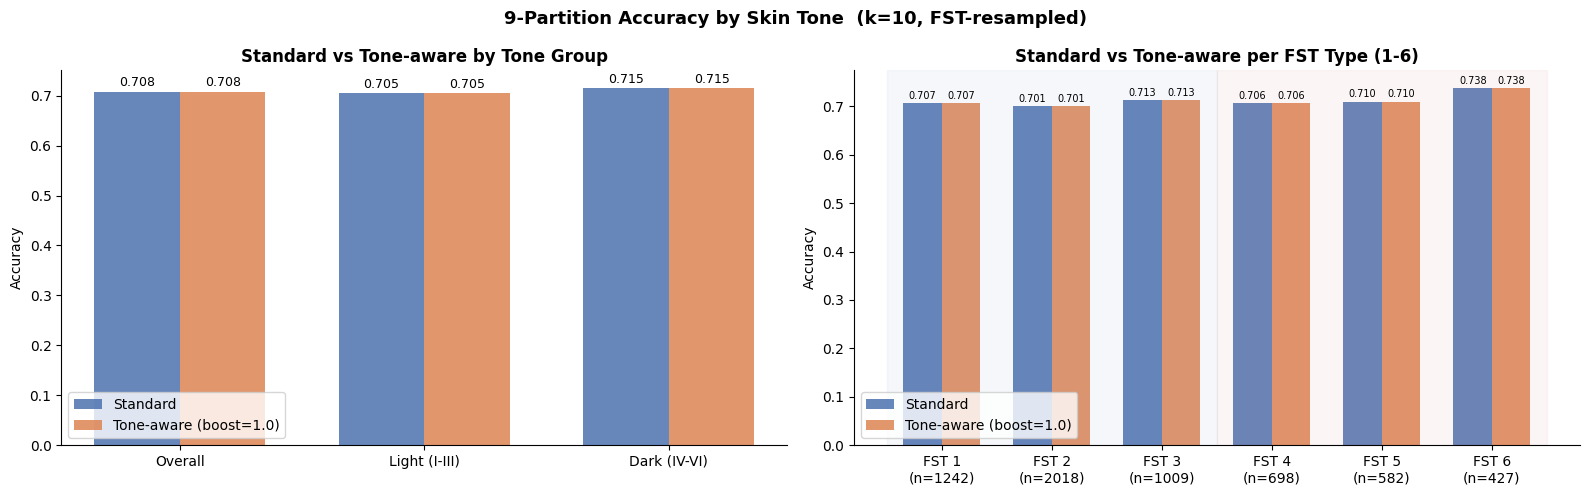

In [17]:
# Overall / Light / Dark + per FST type 1-6
fitz_df  = pred_df[pred_df[FITZ_COL] > 0]
fst_types = sorted(fitz_df[FITZ_COL].unique())

groups    = ['Overall', 'Light (I-III)', 'Dark (IV-VI)']
grp_masks = [
    [True]*len(pred_df),
    pred_df[TONE_COL] == LIGHT_GROUP,
    pred_df[TONE_COL] == DARK_GROUP,
]
grp_std  = [pred_df.loc[m, 'correct_standard'].mean()   for m in grp_masks]
grp_tone = [pred_df.loc[m, 'correct_tone_aware'].mean() for m in grp_masks]

fst_std  = [fitz_df[fitz_df[FITZ_COL]==t]['correct_standard'].mean()   for t in fst_types]
fst_tone = [fitz_df[fitz_df[FITZ_COL]==t]['correct_tone_aware'].mean() for t in fst_types]
fst_ns   = [fitz_df[fitz_df[FITZ_COL]==t].shape[0]                     for t in fst_types]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overall / light / dark
ax = axes[0]
x, w = np.arange(len(groups)), 0.35
b1 = ax.bar(x - w/2, grp_std,  w, label='Standard',              color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, grp_tone, w, label=f'Tone-aware (boost={TONE_BOOST})', color='#DD8452', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Accuracy')
ax.set_title('Standard vs Tone-aware by Tone Group', fontweight='bold')
ax.legend(); sns.despine(ax=ax)

# Right: per FST type 1-6
ax = axes[1]
x2, w2 = np.arange(len(fst_types)), 0.35
b1 = ax.bar(x2 - w2/2, fst_std,  w2, label='Standard',              color='#4C72B0', alpha=0.85)
b2 = ax.bar(x2 + w2/2, fst_tone, w2, label=f'Tone-aware (boost={TONE_BOOST})', color='#DD8452', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7)
# shade background by tone group
ax.axvspan(-0.5, 2.5,             alpha=0.05, color='#4C72B0')
ax.axvspan(2.5,  len(fst_types)-0.5, alpha=0.05, color='#C44E52')
ax.set_xticks(x2)
ax.set_xticklabels([f'FST {t}\n(n={n})' for t, n in zip(fst_types, fst_ns)])
ax.set_ylabel('Accuracy')
ax.set_title('Standard vs Tone-aware per FST Type (1-6)', fontweight='bold')
ax.legend(); sns.despine(ax=ax)

plt.suptitle(f'9-Partition Accuracy by Skin Tone  (k={K}, FST-resampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/tone_group_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Equity Analysis — Dark vs Light Gap per Disease Category

In [18]:
label_col = 'nine_partition_label'

equity = (
    pred_df.groupby([label_col, TONE_COL])
    .agg(std=('correct_standard','mean'), tone=('correct_tone_aware','mean'), n=(TONE_COL,'count'))
    .unstack(TONE_COL)
)
equity.columns = ['_'.join(c).strip() for c in equity.columns]
equity = equity.dropna()

dark_col_std   = [c for c in equity.columns if 'std'  in c and 'Dark'  in c][0]
light_col_std  = [c for c in equity.columns if 'std'  in c and 'Light' in c][0]
dark_col_tone  = [c for c in equity.columns if 'tone' in c and 'Dark'  in c][0]
light_col_tone = [c for c in equity.columns if 'tone' in c and 'Light' in c][0]

equity['gap_standard']   = equity[dark_col_std]  - equity[light_col_std]
equity['gap_tone_aware'] = equity[dark_col_tone] - equity[light_col_tone]
equity['gap_delta']      = equity['gap_tone_aware'] - equity['gap_standard']
equity = equity.sort_values('gap_standard')

print('Dark vs Light accuracy gap per disease category:')
display(equity[['gap_standard', 'gap_tone_aware', 'gap_delta']])


Dark vs Light accuracy gap per disease category:


,gap_standard,gap_tone_aware,gap_delta
nine_partition_label,,,
malignant melanoma,-0.108772,-0.108772,0.0
malignant epidermal,-0.041246,-0.041246,0.0
inflammatory,-0.006174,-0.006174,0.0
malignant cutaneous lymphoma,0.000000,0.000000,0.0
benign epidermal,0.007383,0.007383,0.0
benign dermal,0.024800,0.024800,0.0
benign melanocyte,0.099666,0.099666,0.0
malignant dermal,0.103448,0.103448,0.0
genodermatoses,0.136492,0.136492,0.0


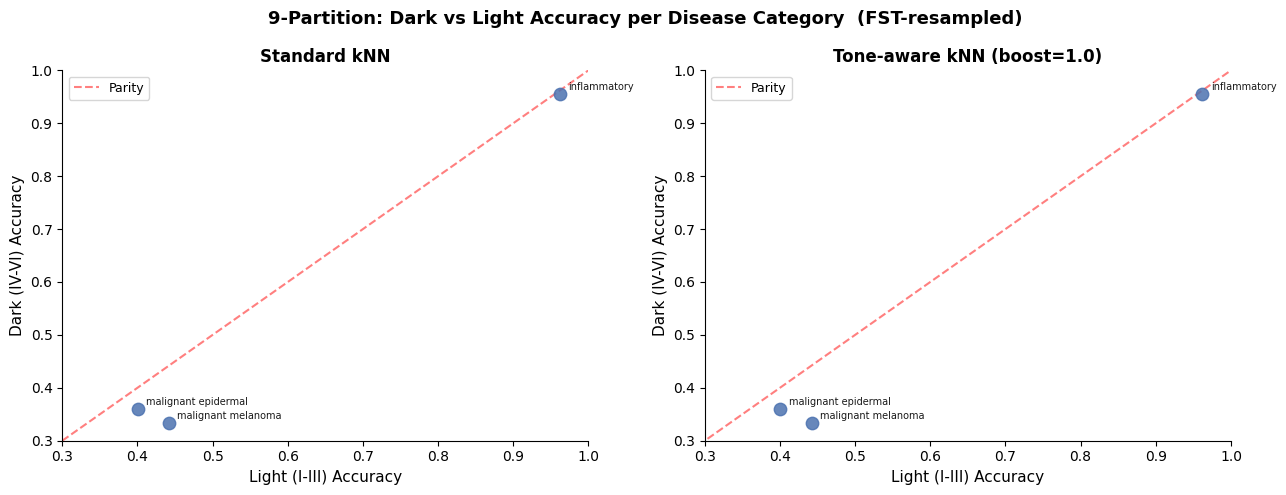

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (dark_col, light_col, method_name) in zip(axes, [
    (dark_col_std,  light_col_std,  'Standard kNN'),
    (dark_col_tone, light_col_tone, f'Tone-aware kNN (boost={TONE_BOOST})'),
]):
    ax.scatter(equity[light_col], equity[dark_col], s=80, alpha=0.85, color='#4C72B0', zorder=3)
    ax.plot([0,1],[0,1], 'r--', alpha=0.5, label='Parity')
    ax.set_xlabel('Light (I-III) Accuracy', fontsize=11)
    ax.set_ylabel('Dark (IV-VI) Accuracy', fontsize=11)
    ax.set_title(method_name, fontweight='bold')
    ax.set_xlim(0.3, 1.0); ax.set_ylim(0.3, 1.0)
    for lbl in equity.index:
        ax.annotate(lbl,
                    (equity.loc[lbl, light_col], equity.loc[lbl, dark_col]),
                    textcoords='offset points', xytext=(6, 3), fontsize=7, alpha=0.9)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('9-Partition: Dark vs Light Accuracy per Disease Category  (FST-resampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/equity_scatter_9partition.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Sweep k and Boost

k sweep (9-partition, FST-resampled)...
  k= 1
  k= 3
  k= 5
  k=10
  k=15
  k=20
  k=30


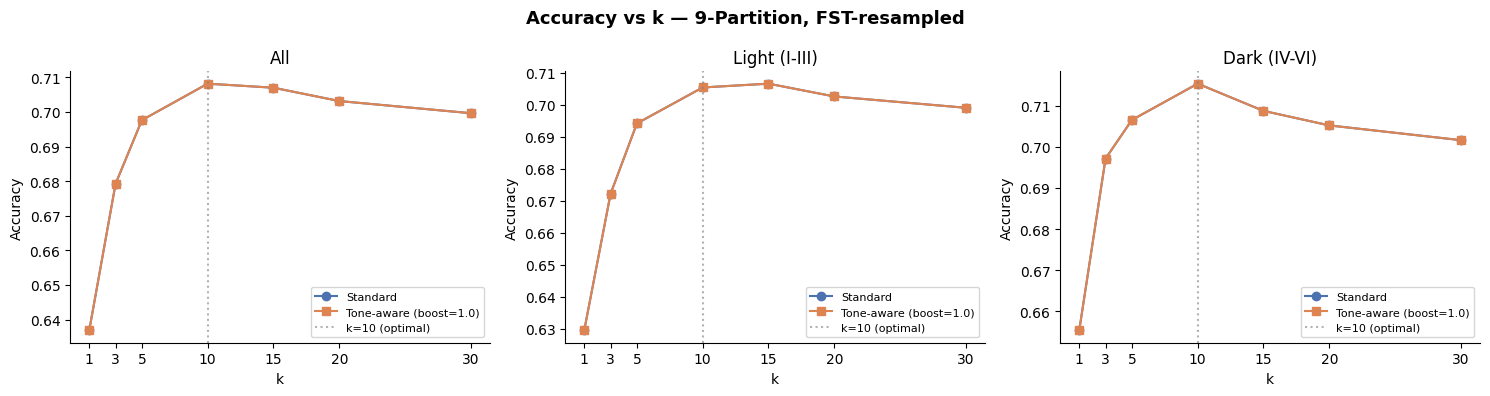

In [20]:
k_values  = [1, 3, 5, 10, 15, 20, 30]
k_sweep   = defaultdict(list)

label_col = 'nine_partition_label'
labels_cv = df_resampled[label_col].values
tones_cv  = df_resampled[TONE_COL].values
skf_cv    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds_cv  = list(skf_cv.split(emb_resampled, labels_cv))

print('k sweep (9-partition, FST-resampled)...')
for k in k_values:
    for group, mask_fn in [
        ('all',   lambda t: np.ones(len(t), bool)),
        ('light', lambda t: t == LIGHT_GROUP),
        ('dark',  lambda t: t == DARK_GROUP),
    ]:
        acc_s, acc_t = [], []
        for tr_idx, te_idx in folds_cv:
            tr_e, tr_l, tr_t = emb_resampled[tr_idx], labels_cv[tr_idx], tones_cv[tr_idx]
            te_e, te_l, te_t = emb_resampled[te_idx], labels_cv[te_idx], tones_cv[te_idx]
            m = mask_fn(te_t)
            if m.sum() == 0: continue
            sp = knn_predict(te_e, tr_e, tr_l, k=k)
            tp = tone_aware_knn_predict(te_e, te_t, tr_e, tr_l, tr_t, k=k)
            acc_s.append(accuracy_score(te_l[m], sp[m]))
            acc_t.append(accuracy_score(te_l[m], tp[m]))
        k_sweep[f'std_{group}'].append(np.mean(acc_s))
        k_sweep[f'tone_{group}'].append(np.mean(acc_t))
    print(f'  k={k:2d}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, grp, title in zip(axes,
    ['all', 'light', 'dark'],
    ['All', 'Light (I-III)', 'Dark (IV-VI)']
):
    ax.plot(k_values, k_sweep[f'std_{grp}'],  marker='o', label='Standard',   color='#4C72B0')
    ax.plot(k_values, k_sweep[f'tone_{grp}'], marker='s', label=f'Tone-aware (boost={TONE_BOOST})',
            color='#DD8452')
    ax.axvline(K, linestyle=':', color='gray', alpha=0.6, label=f'k={K} (optimal)')
    ax.set_xlabel('k'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.set_xticks(k_values); ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.suptitle('Accuracy vs k — 9-Partition, FST-resampled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/k_sweep_9partition.png', dpi=150, bbox_inches='tight')
plt.show()


Boost sweep (9-partition, FST-resampled)...
  boost=1.00 | dark=0.715  light=0.705
  boost=1.10 | dark=0.702  light=0.705
  boost=1.25 | dark=0.701  light=0.705
  boost=1.50 | dark=0.701  light=0.705
  boost=1.75 | dark=0.701  light=0.705
  boost=2.00 | dark=0.701  light=0.705
  boost=2.50 | dark=0.701  light=0.705
  boost=3.00 | dark=0.701  light=0.705

Key finding: boost=1.0 achieves best dark accuracy (0.715)
Max dark accuracy loss from boosting: -0.014
Interpretation: same-tone neighbors are not more label-informative than
globally nearest neighbors at the 9-partition level.


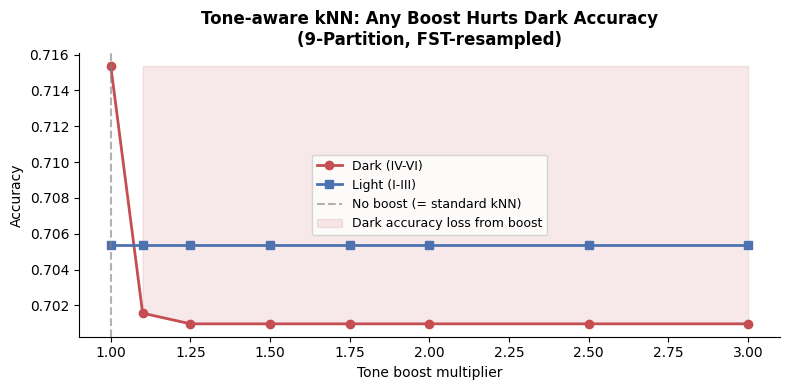

In [21]:
boost_values = [1.0, 1.1, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
boost_dark, boost_light = [], []

print('Boost sweep (9-partition, FST-resampled)...')
for b in boost_values:
    d_acc, l_acc = [], []
    for tr_idx, te_idx in folds_cv:
        tr_e, tr_l, tr_t = emb_resampled[tr_idx], labels_cv[tr_idx], tones_cv[tr_idx]
        te_e, te_l, te_t = emb_resampled[te_idx], labels_cv[te_idx], tones_cv[te_idx]
        tp = tone_aware_knn_predict(te_e, te_t, tr_e, tr_l, tr_t, k=K, boost=b)
        dm = te_t == DARK_GROUP
        lm = te_t == LIGHT_GROUP
        d_acc.append(accuracy_score(te_l[dm], tp[dm]))
        l_acc.append(accuracy_score(te_l[lm], tp[lm]))
    boost_dark.append(np.mean(d_acc))
    boost_light.append(np.mean(l_acc))
    print(f'  boost={b:.2f} | dark={boost_dark[-1]:.3f}  light={boost_light[-1]:.3f}')

baseline_dark = boost_dark[0]
max_loss      = baseline_dark - min(boost_dark)
print(f'\nKey finding: boost=1.0 achieves best dark accuracy ({baseline_dark:.3f})')
print(f'Max dark accuracy loss from boosting: -{max_loss:.3f}')
print('Interpretation: same-tone neighbors are not more label-informative than')
print('globally nearest neighbors at the 9-partition level.')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(boost_values, boost_dark,  marker='o', label='Dark (IV-VI)',  color='#C44E52', linewidth=2)
ax.plot(boost_values, boost_light, marker='s', label='Light (I-III)', color='#4C72B0', linewidth=2)
ax.axvline(1.0, linestyle='--', color='gray', alpha=0.6, label='No boost (= standard kNN)')
ax.fill_between(boost_values, boost_dark, boost_dark[0],
                where=[b > 1.0 for b in boost_values],
                alpha=0.12, color='#C44E52', label='Dark accuracy loss from boost')
ax.set_xlabel('Tone boost multiplier')
ax.set_ylabel('Accuracy')
ax.set_title('Tone-aware kNN: Any Boost Hurts Dark Accuracy\n(9-Partition, FST-resampled)',
             fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/content/boost_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:
# Disease distribution by tone group
dist = (
    pred_df.groupby([TONE_COL, 'nine_partition_label'])
    .size()
    .unstack(TONE_COL)
    .fillna(0)
    .astype(int)
)
dist['light_pct'] = dist[LIGHT_GROUP] / dist[LIGHT_GROUP].sum()
dist['dark_pct']  = dist[DARK_GROUP]  / dist[DARK_GROUP].sum()
dist['skew']      = dist['dark_pct'] - dist['light_pct']

# Also add per-category accuracy
acc = pred_df.groupby('nine_partition_label')['correct_standard'].mean().rename('accuracy')
dist = dist.join(acc).sort_values('skew', ascending=False)
display(dist)

,Dark (IV-VI),Light (I-III),light_pct,dark_pct,skew,accuracy
nine_partition_label,,,,,,
genodermatoses,164,221,0.051769,0.096075,0.044306,0.135065
inflammatory,1175,2836,0.664324,0.688342,0.024018,0.960110
malignant dermal,29,26,0.006090,0.016989,0.010898,0.054545
benign epidermal,106,253,0.059264,0.062097,0.002833,0.089136
malignant cutaneous lymphoma,11,33,0.007730,0.006444,-0.001286,0.000000
benign melanocyte,23,65,0.015226,0.013474,-0.001752,0.056818
benign dermal,96,323,0.075662,0.056239,-0.019423,0.095465
malignant melanoma,39,190,0.044507,0.022847,-0.021660,0.423581
malignant epidermal,64,322,0.075428,0.037493,-0.037935,0.393782
